<a href="https://colab.research.google.com/github/DavendrenG/3_micard/blob/master/ANANDA_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🙏 Ananda Sangha Durban — Poster Generator v4
### Only edit the top cell. Then **Runtime → Run all**.

In [ ]:
# ============================================================
#  ✏️ CHANGE ONLY THESE LINES FOR EACH NEW POSTER
# ============================================================

TITLE_LINE1  = 'Experience of God'
TITLE_LINE2  = 'Meditation'
DATE         = 'Thursday, 19 March 2026'
TIME         = '18 : 30  –  19 : 15'
HOST         = 'Davendren'
PLATFORM     = 'ZOOM  ·  45 Minutes  ·  Online'
QUOTE        = '"Spreading the teachings of Paramhansa Yogananda"'

# ── Upload your background photo in the Files panel ──────────
# Change this to match your uploaded filename
BACKGROUND_FILE = 'background.jpg'

# ── logo.jpeg and lineage.jpeg are permanent ─────────────────
# Upload them ONCE. They stay in Colab for all future sessions.
# Filenames are fixed — no need to rename anything.
LOGO_FILE    = 'logo.jpeg'
LINEAGE_FILE = 'lineage.jpeg'

print('Details set! ✅')

Details set! ✅


In [ ]:
# ⚙️ Install fonts — runs in ~10 sec
import subprocess
subprocess.run(['apt-get','install','-y','-q','fonts-freefont-ttf','fonts-liberation'], check=True)
print('Fonts ready ✅')

Fonts ready ✅


## 🖼️ Upload images before running the next cell
In the **Files panel** (folder icon, left sidebar) upload:
- Your **background photo** (name must match BACKGROUND_FILE above)
- **logo.jpeg** — upload once, stays forever
- **lineage.jpeg** — upload once, stays forever

Auto-detected details start: y=720
Logo size: 500x500
Logo placed ✅

✅ DONE! Right-click poster_output.png in Files panel → Download


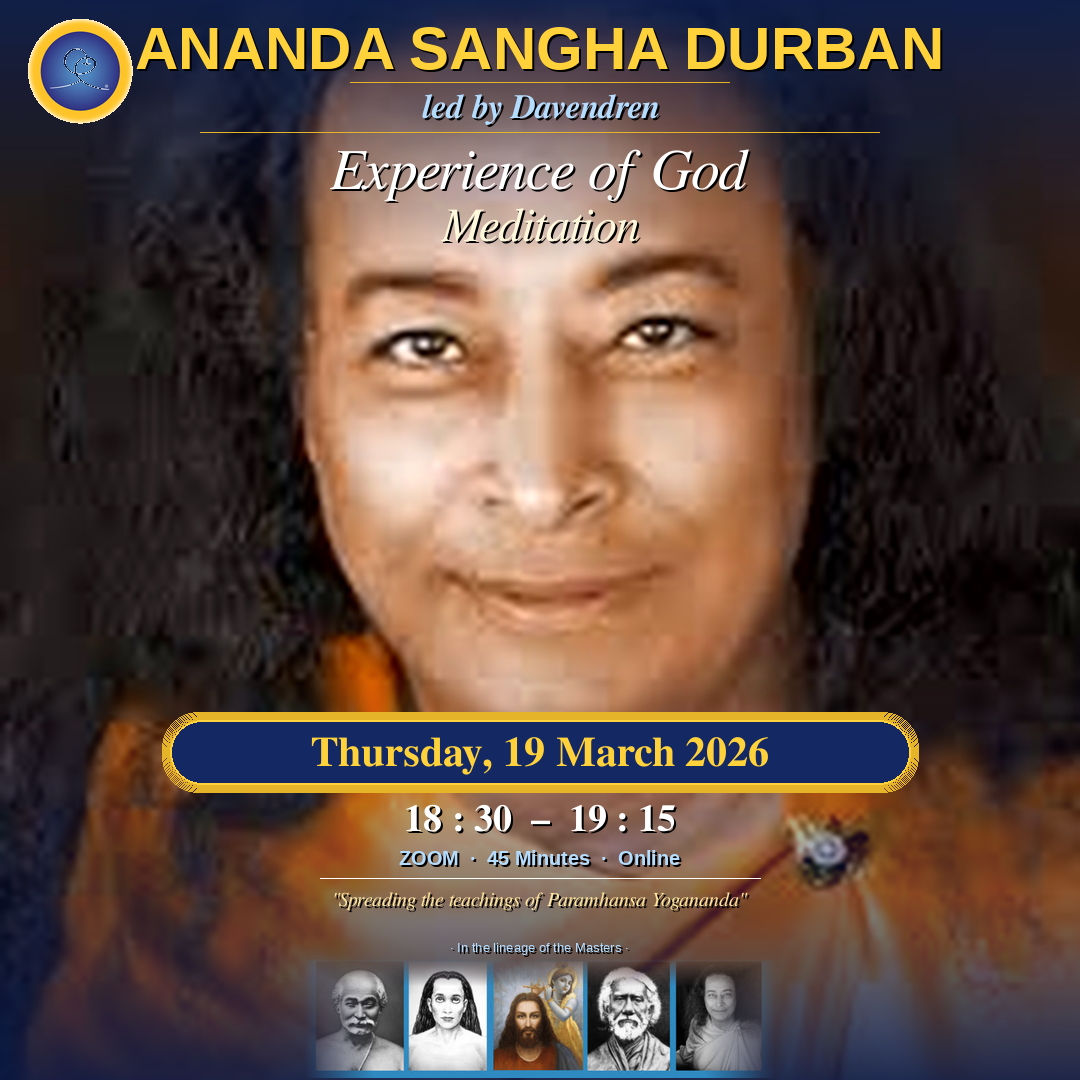

In [ ]:
# 🎨 GENERATE POSTER
from PIL import Image, ImageDraw, ImageFont, ImageEnhance
import numpy as np

W, H   = 1080, 1080
WHITE  = (255, 255, 255)
CREAM  = (255, 248, 220)
GOLD   = (255, 210,  60)
GOLD2  = (230, 180,  40)
LTBLUE = (180, 220, 255)

FI  = '/usr/share/fonts/truetype/freefont/FreeSerifItalic.ttf'
FB  = '/usr/share/fonts/truetype/freefont/FreeSerifBold.ttf'
FBI = '/usr/share/fonts/truetype/freefont/FreeSerifBoldItalic.ttf'
FSB = '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf'
FSR = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'

def ctext(d, text, y, font, color, width=W, shadow=True):
    bb = d.textbbox((0,0), text, font=font)
    tw = bb[2]-bb[0]
    x  = (width-tw)//2
    if shadow: d.text((x+2,y+2), text, font=font, fill=(0,0,0,150))
    d.text((x,y), text, font=font, fill=color)
    return tw

def gold_line(d, y, left=200, right=W-200, alpha=180):
    for x in range(left, right):
        t=(x-left)/(right-left); a=int(alpha*4*t*(1-t))
        d.point((x,y), fill=(*GOLD2,a))

def fit_font(draw, text, path, max_width, start=60, min_size=20):
    for size in range(start, min_size-1, -1):
        f = ImageFont.truetype(path, size)
        bb = draw.textbbox((0,0), text, font=f)
        if bb[2]-bb[0] <= max_width:
            return f, size
    return ImageFont.truetype(path, min_size), min_size

# ── Canvas sky-blue gradient ──────────────────────────────────
canvas = Image.new('RGBA',(W,H))
draw   = ImageDraw.Draw(canvas)
for y in range(H):
    t=y/H
    draw.line([(0,y),(W,y)],fill=(int(30+(50-30)*t),int(140+(115-140)*t),int(205+(175-205)*t),255))

# ── Background photo full bleed ───────────────────────────────
bg = Image.open(BACKGROUND_FILE).convert('RGBA')
bw,bh = bg.size
scale = max(W/bw, H/bh)
bg = bg.resize((int(bw*scale),int(bh*scale)),Image.LANCZOS)
ox=(bg.width-W)//2; oy=(bg.height-H)//2
bg = bg.crop((ox,oy,ox+W,oy+H))
bg = ImageEnhance.Brightness(
     ImageEnhance.Color(bg.convert('RGB')).enhance(1.15)
     ).enhance(1.05).convert('RGBA')
canvas.paste(bg,(0,0))

# ── Auto-detect brightest row in bottom half ──────────────────
# Find where the subject's face/body ends so text goes below it
bg_arr = np.array(bg.convert('RGB'))
# Look at bottom half of image only
bottom_half = bg_arr[H//2:, :, :]
row_brightness = bottom_half.mean(axis=(1,2))
# Find last row that is reasonably bright (subject still present)
bright_rows = np.where(row_brightness > 60)[0]
if len(bright_rows) > 0:
    last_bright = bright_rows[-1] + H//2
    # Text block starts 20px below where subject ends, min 640, max 720
    details_start = max(640, min(720, last_bright - 80))
else:
    details_start = 680
print(f'Auto-detected details start: y={details_start}')

# ── Top dark gradient ─────────────────────────────────────────
tg=Image.new('RGBA',(W,H),(0,0,0,0)); tgd=ImageDraw.Draw(tg)
for y in range(280):
    a=int(215*(1-y/280)**1.2)
    tgd.line([(0,y),(W,y)],fill=(10,30,80,a))
canvas=Image.alpha_composite(canvas,tg)

# ── Bottom dark gradient — from details_start down ────────────
bg2=Image.new('RGBA',(W,H),(0,0,0,0)); bg2d=ImageDraw.Draw(bg2)
fade_start = details_start - 60
fade_range = H - fade_start
for y in range(fade_start, H):
    t=(y-fade_start)/fade_range; a=int(235*t**1.1)
    bg2d.line([(0,y),(W,y)],fill=(10,25,70,a))
canvas=Image.alpha_composite(canvas,bg2)
draw=ImageDraw.Draw(canvas)

# ── Fonts ─────────────────────────────────────────────────────
f_sangha,sz = fit_font(draw,'ANANDA SANGHA DURBAN',FSB,W-30,start=60)
f_led = ImageFont.truetype(FBI,34)
f_m1  = ImageFont.truetype(FI,58)
f_m2  = ImageFont.truetype(FI,48)
f_dt  = ImageFont.truetype(FB,42)
f_tm  = ImageFont.truetype(FB,38)
f_zm  = ImageFont.truetype(FSB,20)
f_qt  = ImageFont.truetype(FI,20)
f_ln  = ImageFont.truetype(FSR,13)

# ── Header ────────────────────────────────────────────────────
y=14
ctext(draw,'ANANDA SANGHA DURBAN',y,f_sangha,GOLD)
y+=sz+8
gold_line(draw,y,left=350,right=W-350,alpha=140); y+=8
ctext(draw,'led by '+HOST,y,f_led,LTBLUE); y+=42
gold_line(draw,y,left=200,right=W-200,alpha=180); y+=10
ctext(draw,TITLE_LINE1,y,f_m1,WHITE); y+=60
ctext(draw,TITLE_LINE2,y,f_m2,CREAM)

# ── Bottom details — positioned dynamically ───────────────────
by = details_start
pw,ph=740,64; px=(W-pw)//2
for i in range(8,0,-1):
    draw.rounded_rectangle([px-i,by-i,px+pw+i,by+ph+i],radius=36,outline=(*GOLD2,25*i//8))
draw.rounded_rectangle([px,by,px+pw,by+ph],radius=32,fill=(20,40,100,220),outline=(*GOLD,220),width=2)
ctext(draw,DATE,by+12,f_dt,GOLD,shadow=False)
by+=ph+16
ctext(draw,TIME,by,f_tm,WHITE); by+=46
ctext(draw,PLATFORM,by,f_zm,LTBLUE); by+=30
draw.line([(320,by+2),(W-320,by+2)],fill=(255,255,255,50),width=1); by+=14
ctext(draw,QUOTE,by,f_qt,(255,230,160))

# ── Ananda Logo — removes BOTH black and white backgrounds ────
logo_raw = Image.open(LOGO_FILE).convert('RGBA')
lw,lh    = logo_raw.size
print(f'Logo size: {lw}x{lh}')

# Crop if large original file
if lw > 600:
    pad = 30
    logo_raw = logo_raw.crop((max(0,58-pad),max(0,882-pad),
                               min(lw,1381+pad),min(lh,2205+pad)))

logo_sm = logo_raw.resize((115,115),Image.LANCZOS)
logo_arr = np.array(logo_sm).astype(float)
la = np.array(logo_sm)

# Remove dark (black/navy) background
dark_mask  = (logo_arr[:,:,0]+logo_arr[:,:,1]+logo_arr[:,:,2]) < 80
# Remove light (white/cream) background
light_mask = ((logo_arr[:,:,0] > 200) &
              (logo_arr[:,:,1] > 200) &
              (logo_arr[:,:,2] > 200))
la[dark_mask | light_mask, 3] = 0

logo_img = Image.fromarray(la)
canvas.paste(logo_img,(22,14),logo_img)
print('Logo placed ✅')

# ── Lineage strip ─────────────────────────────────────────────
lin = Image.open(LINEAGE_FILE).convert('RGBA')
arr_l = np.array(lin.convert('RGB'))
rows  = np.where(arr_l.mean(axis=(1,2))>20)[0]
lin   = lin.crop((0,rows[0],lin.width,rows[-1])) if len(rows) else lin
strip = lin.crop((0,int(lin.height*0.45),lin.width,lin.height))
lth   = 120
lrs   = strip.resize((int(strip.size[0]*(lth/strip.size[1])),lth),Image.LANCZOS)
lrw,lrh = lrs.size
lin_r = lrs.convert('RGBA')
lmask = Image.new('L',(lrw,lrh),255)
fpx   = 70
for x in range(lrw):
    a=int(255*x/fpx) if x<fpx else int(255*(lrw-x)/fpx) if x>lrw-fpx else 255
    for y2 in range(lrh): lmask.putpixel((x,y2),min(lmask.getpixel((x,y2)),a))
for y2 in range(28):
    a=int(255*y2/28)
    for x in range(lrw): lmask.putpixel((x,y2),min(lmask.getpixel((x,y2)),a))
lin_r.putalpha(lmask)
lx2=(W-lrw)//2; ly2=H-lth-2
cn2=canvas.convert('RGBA'); cn2.paste(lin_r,(lx2,ly2),lin_r); canvas=cn2
draw=ImageDraw.Draw(canvas)
ctext(draw,'\u00b7 In the lineage of the Masters \u00b7',ly2-18,f_ln,LTBLUE)

# ── Save & preview ────────────────────────────────────────────
canvas.convert('RGB').save('poster_output.png','PNG',quality=97)
print('\n✅ DONE! Right-click poster_output.png in Files panel → Download')
from IPython.display import Image as IPImage
IPImage('poster_output.png', width=540)